In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt


95
95


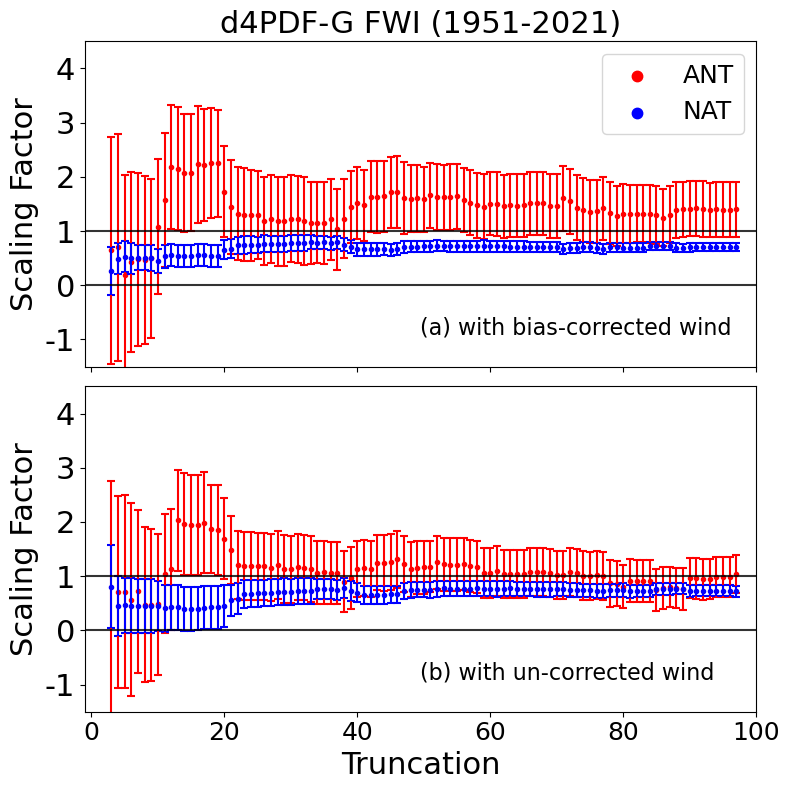

In [3]:
font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 22,
        }

fig,axs = plt.subplots(2, 1, figsize=(8,8), sharex=True, sharey=True)

axs = axs.flatten()

model = 'd4pdf'
start = '1951'
end = '2021'
    
for i,d4PDF_BC_flag in enumerate([True,False]):

    plot_saved_result(model,axs[i],start,end,font,d4PDF_BC_flag)
    
    
axs[0].set_title('d4PDF-G FWI (' + start + '-' + end + ')',fontdict=font)
axs[0].legend(fontsize=18,loc='upper right', markerscale=2.5)

for ax in axs:
    ax.set_ylabel('Scaling Factor',fontdict=font)
    ax.set_yticks([-1,0,1,2,3,4])
    ax.set_yticklabels(['-1','0','1','2','3','4'],fontdict=font)
    
axs[1].set_xlabel('Truncation',fontdict=font)

font['size'] = 18

#plt.subplots_adjust(wspace=0.05)
#plt.subplots_adjust(hspace=None)#, hspace=None)
plt.tight_layout()
plt.savefig(f'/home/queenle/fire_attribution/figures/sup_mat/SM_Fig7.png',dpi=300)


In [2]:
def plot_saved_result(model,ax,start_year,end_year,font,d4PDF_BC=True):

    df = pd.read_csv('/home/queenle/fire_attribution/result_files/'+model+'_scan_beta_results_'+start_year+'_'+end_year+'_d4PDFwindBC_'+str(d4PDF_BC)+'.csv')

    print(len(df['Truncation']))
    
    ax.scatter(df['Truncation'],df['ant_best'],color='red',marker='.',label='ANT')
    ax.scatter(df['Truncation'],df['ant_upper'],color='red',marker='_')
    ax.scatter(df['Truncation'],df['ant_lower'],color='red',marker='_')
    ax.vlines(df['Truncation'],df['ant_lower'],df['ant_upper'],color='red')

    ax.scatter(df['Truncation'],df['nat_best'],color='blue',marker='.',label='NAT')
    ax.scatter(df['Truncation'],df['nat_upper'],color='blue',marker='_')
    ax.scatter(df['Truncation'],df['nat_lower'],color='blue',marker='_')
    ax.vlines(df['Truncation'],df['nat_lower'],df['nat_upper'],color='blue')

    ax.axhline(0,-0.5,1.5,c='black',alpha=0.8)
    ax.axhline(1,-0.5,1.5,c='black',alpha=0.8)
    ax.set_ylim(-1.5,4.5)
    
    font['size'] = 18
    ax.set_xlim(-1,100)
    ax.set_xticks([20*i for i in range(6)])
    ax.set_xticklabels([str(20*i) for i in range(6)],fontdict=font)
    font['size'] = 22
    
    font['size']=16
    if d4PDF_BC:
        ax.text(0.5,0.1,'(a) with bias-corrected wind',fontdict=font,transform=ax.transAxes)
        
    if not d4PDF_BC:
        ax.text(0.5,0.1,'(b) with un-corrected wind',fontdict=font,transform=ax.transAxes)
    font['size'] = 22

    